In [88]:
import numpy as np
import pandas as pd

In [89]:
print(np.__version__)
print(pd.__version__)

1.24.3
2.0.3


In [90]:
df = pd.read_csv("cleaned_canada.csv")

In [91]:
df.shape

(44896, 23)

In [92]:
df.head()

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Exterior,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,NaN,No,heat pump,carpet,NaN,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,NaN,No,heat pump,NaN,NaN,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,Metal,No,NaN,laminate,tar,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,NaN,Yes,forced air,NaN,NaN,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,NaN,No,radiant,NaN,NaN,No,none,No,No,No


In [93]:
df.columns

Index(['City', 'Province', 'Latitude', 'Longitude', 'Price', 'Bedrooms',
       'Bathrooms', 'Acreage', 'Property Type', 'Square Footage', 'Garage',
       'Parking', 'Basement', 'Exterior', 'Fireplace', 'Heating', 'Flooring',
       'Roof', 'Waterfront', 'Sewer', 'Pool', 'Garden', 'Balcony'],
      dtype='object')

In [94]:
df =df[['City', 'Province', 'Price', 'Bedrooms', 'Bathrooms', 'Property Type', 'Square Footage', 'Garage', 'Pool', 'Garden', 'Balcony']]

In [95]:
df = df.drop_duplicates()

In [96]:
df.shape

(40357, 11)

In [97]:
df.sample(8)

,City,Province,Price,Bedrooms,Bathrooms,Property Type,Square Footage,Garage,Pool,Garden,Balcony
23634,Langford,BC,534900.0,2.0,2.0,Condo,955.0,Yes,No,No,Yes
19777,Tsawwassen,BC,2279999.0,5.0,3.0,Single Family,4265.0,Yes,No,No,No
25372,Vancouver,BC,989500.0,2.0,2.0,Condo,837.0,Yes,No,No,No
10549,Burnaby,BC,1299800.0,2.0,3.0,Townhome,1209.0,Yes,No,No,No
26575,Rosetown,SK,165000.0,4.0,2.0,Single Family,816.0,Yes,No,No,No
21023,Surrey,BC,1249000.0,4.0,4.0,Townhome,1832.0,Yes,No,No,No
182,Rural Rocky View County,AB,1949900.0,5.0,6.0,Single Family,4189.0,Yes,No,No,No
8703,Langley,BC,2208000.0,4.0,2.0,Single Family,1938.0,Yes,No,No,No


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40357 entries, 0 to 44894
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            40357 non-null  object 
 1   Province        40357 non-null  object 
 2   Price           40357 non-null  float64
 3   Bedrooms        40357 non-null  float64
 4   Bathrooms       40357 non-null  float64
 5   Property Type   40357 non-null  object 
 6   Square Footage  40357 non-null  float64
 7   Garage          40357 non-null  object 
 8   Pool            40357 non-null  object 
 9   Garden          40357 non-null  object 
 10  Balcony         40357 non-null  object 
dtypes: float64(4), object(7)
memory usage: 3.7+ MB


In [99]:
import seaborn as sns

C:\Users\b4bik\AppData\Local\Temp\ipykernel_12820\545004788.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=np.log(df['Price']))


<Axes: ylabel='Density'>

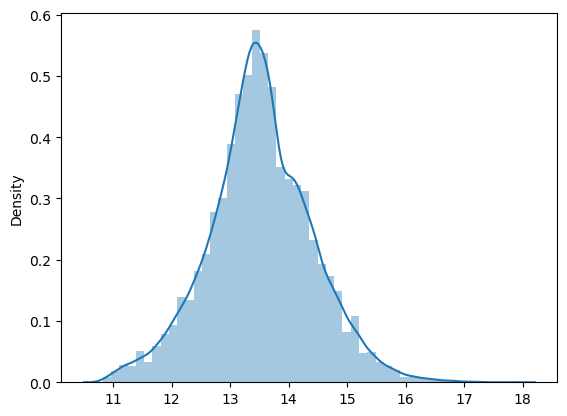

In [100]:
sns.distplot(x=np.log(df['Price']))

In [101]:
df['City'].value_counts()

City
Vancouver           3822
Surrey              3424
Calgary             1587
Richmond            1368
Kelowna             1334
                    ... 
Clifton Royal          1
New Germany            1
Morell East            1
Head of Montague       1
Drayton Valley         1
Name: count, Length: 3149, dtype: int64

In [102]:
df['Province'].value_counts()

Province
BC    22753
AB     4008
ON     3611
SK     3606
NS     2198
NB     1954
NL     1374
PE      734
MB       67
YT       40
NT       12
Name: count, dtype: int64

In [103]:
df.groupby("Province")["City"].nunique()

Province
AB    237
BC    241
MB     26
NB    483
NL    399
NS    733
NT      4
ON    353
PE    199
SK    584
YT      8
Name: City, dtype: int64

In [104]:
df['Property Type'].value_counts()

Property Type
Single Family        23606
Condo                11637
Townhome              2132
Condo/Townhome        1450
Duplex                 874
MultiFamily            269
Manufactured Home      209
Mobile Home            165
Vacant Land             15
Name: count, dtype: int64

In [105]:
df = df[df['Property Type'] != 'Condo/Townhome']
df.shape

(38907, 11)

In [106]:
mapping = {
    "Single Family": "Single Family",
    "Townhome": "Townhome",
    "Condo": "Condo",
    "Duplex": "Multi",
    "MultiFamily": "Multi",
    "Manufactured Home": "Other",
    "Mobile Home": "Other",
    "Vacant Land": "Other"
}

df["Property Type"] = df["Property Type"].map(mapping)
df.sample(8)

,City,Province,Price,Bedrooms,Bathrooms,Property Type,Square Footage,Garage,Pool,Garden,Balcony
32693,Belliveaus Cove,NS,189000.0,2.0,1.0,Single Family,840.0,No,No,No,No
4102,Fort McMurray,AB,574900.0,7.0,3.0,Single Family,1576.0,Yes,No,Yes,Yes
9013,Langley,BC,5500000.0,4.0,1.0,Single Family,1838.0,No,No,No,No
5676,Calgary,AB,685000.0,5.0,4.0,Single Family,1688.0,Yes,No,No,No
35819,Ketch Harbour,NS,439900.0,3.0,2.0,Single Family,1000.0,No,No,No,No
2312,Surrey,BC,499900.0,2.0,2.0,Condo,746.0,Yes,No,No,No
35913,Sydney,NS,799000.0,4.0,2.0,Single Family,1902.0,No,No,No,No
6879,Abbotsford,BC,349900.0,3.0,2.0,Condo,1130.0,No,No,No,No


In [107]:
df['Property Type'].value_counts()

Property Type
Single Family    23606
Condo            11637
Townhome          2132
Multi             1143
Other              389
Name: count, dtype: int64

In [108]:
yes_no_cols = ['Garage', 'Pool', 'Garden', 'Balcony']
for i in yes_no_cols:
    df[i] = df[i].map({'Yes': 1, 'No': 0})
df

,City,Province,Price,Bedrooms,Bathrooms,Property Type,Square Footage,Garage,Pool,Garden,Balcony
0,Revelstoke,BC,839000.0,3.0,2.0,Condo,891.0,1,0,0,0
1,Boswell,BC,1150000.0,3.0,2.0,Single Family,1881.0,1,0,0,0
2,West Kelowna,BC,149000.0,2.0,1.0,Single Family,912.0,0,0,0,0
3,Kelowna,BC,1298000.0,5.0,4.0,Single Family,4374.0,1,0,0,0
4,Maple Ridge,BC,759900.0,3.0,2.0,Condo,1254.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
44159,Prince Albert,SK,169900.0,4.0,2.0,Single Family,616.0,1,0,0,0
44401,Regina,SK,529900.0,5.0,3.0,Single Family,1319.0,1,0,0,0
44493,Saskatoon,SK,1599000.0,5.0,5.0,Single Family,2095.0,1,0,0,0
44790,Swift Current,SK,125000.0,2.0,1.0,Single Family,1146.0,1,0,0,0


In [109]:
prov_freq = df['Province'].value_counts().to_dict()



In [110]:
import json

with open("province_freq.json", "w") as f:
    json.dump(prov_freq, f)



In [111]:
print(json.__version__)

2.0.9


In [112]:
city_freq_nested = {}

for (prov, city), freq in df.groupby("Province")["City"].value_counts().to_dict().items():
    if prov not in city_freq_nested:
        city_freq_nested[prov] = {}
    city_freq_nested[prov][city] = int(freq)   # convert np.int64 → int


In [113]:
with open("city_freq.json", "w") as f:
    json.dump(city_freq_nested, f)

In [114]:
# 1) Remove unrealistic Square Footage
sqft_99 = df['Square Footage'].quantile(0.99)
df = df[df['Square Footage'] <= sqft_99]

# # 2) Remove unrealistic bedroom counts
df = df[df['Bedrooms'] <= 10]

# # 3) Remove unrealistic bathroom counts
df = df[df['Bathrooms'] <= 10]

city_freq = df['City'].value_counts()
df['City_freq'] = df['City'].map(city_freq)
df = df.drop(columns=['City'])

prov_freq = df['Province'].value_counts()
df['Prov_freq'] = df['Province'].map(prov_freq)
df = df.drop(columns=['Province'])



In [115]:
df.describe()

,Price,Bedrooms,Bathrooms,Square Footage,Garage,Pool,Garden,Balcony,City_freq,Prov_freq
count,3.845500e+04,38455.000000,38455.000000,38455.000000,38455.000000,38455.000000,38455.000000,38455.000000,38455.000000,38455.000000
mean,1.073110e+06,3.185151,2.471330,1750.438018,0.708907,0.001612,0.038331,0.049486,953.114836,13151.248134
std,1.208148e+06,1.572255,1.338079,1082.287081,0.454272,0.040121,0.191995,0.216884,1215.173928,9187.574048
min,5.000000e+04,0.000000,0.000000,140.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000
25%,4.299000e+05,2.000000,2.000000,960.000000,0.000000,0.000000,0.000000,0.000000,35.000000,3476.000000
50%,7.090000e+05,3.000000,2.000000,1429.000000,1.000000,0.000000,0.000000,0.000000,414.000000,21353.000000
75%,1.294450e+06,4.000000,3.000000,2247.000000,1.000000,0.000000,0.000000,0.000000,1267.000000,21353.000000
max,3.200000e+07,10.000000,10.000000,6574.000000,1.000000,1.000000,1.000000,1.000000,3648.000000,21353.000000


In [30]:
import sklearn

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
print(sklearn.__version__)

1.3.0


In [33]:
import pandas as pd

cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64','float64']).drop('Price', axis=1).columns


In [34]:
cat_cols

Index(['Property Type'], dtype='object')

In [35]:
num_cols

Index(['Bedrooms', 'Bathrooms', 'Square Footage', 'Garage', 'Pool', 'Garden',
       'Balcony', 'City_freq', 'Prov_freq'],
      dtype='object')

In [36]:
df[num_cols[0:3]].describe()

,Bedrooms,Bathrooms,Square Footage
count,38455.000000,38455.000000,38455.000000
mean,3.185151,2.471330,1750.438018
std,1.572255,1.338079,1082.287081
min,0.000000,0.000000,140.000000
25%,2.000000,2.000000,960.000000
50%,3.000000,2.000000,1429.000000
75%,4.000000,3.000000,2247.000000
max,10.000000,10.000000,6574.000000


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler, PowerTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', PowerTransformer(method='yeo-johnson', standardize=True), ['Bedrooms', 'Bathrooms', 'Square Footage', 'City_freq', 'Prov_freq']),
        
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'), ['Property Type']),
        ('binary', 'passthrough', ['Garage', 'Pool', 'Garden', 'Balcony'])
    ],
    remainder='drop'
)


In [38]:
!pip install xgboost
!pip install catboost 


In [39]:
import catboost

In [40]:
print(catboost.__version__)

1.2.8


In [49]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [42]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "SGDRegressor": SGDRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=400,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        n_jobs=-1,),
    "ExtraTrees": ExtraTreesRegressor( n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        n_jobs=-1),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",  
        n_jobs=-1
    ),
    
    'CatBoost': CatBoostRegressor(
        depth=8,learning_rate=0.07,iterations=1000, loss_function = 'RMSE'),

    'Light': LGBMRegressor(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
       
    )}

In [43]:
from sklearn.pipeline import Pipeline

In [44]:
pipe_cb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models["CatBoost"])
])

pipe_cb.fit(X_train, np.log1p(y_train)) 
preds =  np.expm1(pipe_cb.predict(X_test))


r2 = r2_score(y_test, preds)
r2



0:	learn: 0.8372462	total: 172ms	remaining: 2m 52s
1:	learn: 0.8010867	total: 181ms	remaining: 1m 30s
2:	learn: 0.7675341	total: 189ms	remaining: 1m 2s
3:	learn: 0.7349479	total: 197ms	remaining: 49s
4:	learn: 0.7064949	total: 204ms	remaining: 40.7s
5:	learn: 0.6803583	total: 211ms	remaining: 35s
6:	learn: 0.6566817	total: 218ms	remaining: 30.9s
7:	learn: 0.6347850	total: 225ms	remaining: 27.9s
8:	learn: 0.6150385	total: 232ms	remaining: 25.5s
9:	learn: 0.5965751	total: 238ms	remaining: 23.6s
10:	learn: 0.5793471	total: 245ms	remaining: 22s
11:	learn: 0.5645963	total: 251ms	remaining: 20.7s
12:	learn: 0.5510911	total: 258ms	remaining: 19.6s
13:	learn: 0.5391024	total: 265ms	remaining: 18.7s
14:	learn: 0.5268758	total: 271ms	remaining: 17.8s
15:	learn: 0.5160582	total: 278ms	remaining: 17.1s
16:	learn: 0.5059000	total: 284ms	remaining: 16.4s
17:	learn: 0.4976641	total: 291ms	remaining: 15.9s
18:	learn: 0.4904671	total: 297ms	remaining: 15.4s
19:	learn: 0.4835379	total: 304ms	remaining: 

0.7455037396940678

In [45]:
pipe_xg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models["XGBoost"])
])

pipe_xg.fit(X_train, np.log1p(y_train)) 
preds = pipe_xg.predict(X_test)


r2 = r2_score(y_test, np.expm1(preds))
r2

0.7398542967973332

In [51]:
mean_absolute_percentage_error(y_test, np.expm1(preds))

0.24924263076828518

In [47]:
import joblib
joblib.dump(pipe_cb, "house_price_model.pkl")


['house_price_model.pkl']

In [48]:
print(joblib.__version__)

1.2.0
